# Analyzing Profit Erosion from Product Returns in E-Commerce

## A Multi-Method Analytics Framework

**Course**: DAMO-699-4 - Winter 2026 Capstone Project  
**Institution**: University of Niagara Falls, Canada  
**Professor**: Omid Isfahanialamdari

---

## Research Questions

| RQ | Focus | Method |
|----|-------|--------|
| RQ1 | Profit erosion differences across product categories/brands | Descriptive Analysis |
| RQ2 | Customer behavioral segments with differential profit erosion | Unsupervised Learning (Clustering) |
| RQ3 | Predict high profit erosion customers (target AUC > 0.70) | Predictive Modeling (ML) |
| RQ4 | Marginal associations between behaviors and profit erosion | Econometric Regression |
| RQ5 | Optimal intervention thresholds (Optional) | Prescriptive Analytics |

---

## Key Metrics

- **Margin Reversal**: `sale_price - cost` for returned items
- **Processing Cost**: Estimated cost per return (category-adjusted)
- **Profit Erosion**: `margin_reversal + processing_cost` (for returned items only)

---

## Notebook Structure

1. **Setup** - Environment configuration and module imports
2. **Data Loading** - Build raw merged dataset from source files
3. **Data Cleaning** - Quality validation and flagging
4. **Feature Engineering** - Apply return flags, margins, profit erosion calculations
5. **RQ1: Descriptive Analysis** - Profit erosion by category/brand
6. **RQ2: Customer Segmentation** - Clustering by return behavior
7. **RQ3: Predictive Modeling** - ML models for high-risk identification
8. **RQ4: Econometric Analysis** - Regression analysis
9. **Summary & Conclusions**

---

## 1. Setup and Imports

In [1]:
# Standard library imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Reload modules to ensure latest changes are loaded
import importlib
modules_to_reload = [
    'src.config',
    'src.data_processing',
    'src.feature_engineering',
    'src.data_cleaning',
    'src.visualization',
    'src.analytics'
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project configuration
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, PROCESSED_PARQUET

# Data processing (raw data only)
from src.data_processing import (
    load_raw_data,
    merge_datasets,
    standardize_dtypes,
    build_analysis_dataset,
    load_processed_data,
)

# Feature engineering (US06 implementation)
from src.feature_engineering import (
    engineer_return_features,
    calculate_margins,
    calculate_profit_erosion,
    aggregate_profit_erosion_by_order,
    aggregate_profit_erosion_by_customer,
    summarize_profit_erosion,
    engineer_customer_behavioral_features,
    create_profit_erosion_targets,
    save_feature_engineered_dataset,
    CATEGORY_TIER_MULTIPLIERS,
    DEFAULT_COST_COMPONENTS,
)

# Data cleaning
from src.data_cleaning import (
    perform_deep_clean,
    save_cleaned_dataset,
)

# Visualization
from src.visualization import (
    set_plot_style,
    plot_status_distribution,
    plot_return_rate_by_category,
    plot_margin_distribution,
    plot_margin_loss_by_category,
    plot_customer_margin_exposure,
    plot_return_rate_heatmap,
    plot_price_margin_returned_by_status_country,
)

# Analytics (descriptive analysis functions)
from src.analytics import (
    calculate_return_rates_by_group,
    calculate_margin_loss_by_group,
    calculate_customer_margin_exposure,
    segment_customers_by_return_behavior,
    calculate_price_margin_returned_by_country,
)

# Set plotting style
set_plot_style()

print(f"Project root: {project_root}")
print(f"Raw data dir: {RAW_DATA_DIR}")
print(f"Processed data dir: {PROCESSED_DATA_DIR}")
print("\n✓ All modules loaded successfully")

Project root: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project
Raw data dir: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\raw
Processed data dir: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed

✓ All modules loaded successfully


---

## 2. Data Loading

Build the raw merged dataset from source CSV files. The `build_analysis_dataset()` function:
1. Loads raw CSV files (order_items, orders, products, users)
2. Merges them at order-item grain level
3. Standardizes data types
4. Saves to parquet/csv for future use

In [2]:
# Build raw merged dataset from source files
# This loads, merges, and standardizes types - no feature engineering applied yet
print("Building raw merged dataset from source files...")
df_raw = build_analysis_dataset(save_output=True)

print(f"\nDataset built:")
print(f"  Rows: {len(df_raw):,}")
print(f"  Columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())

Building raw merged dataset from source files...

Dataset built:
  Rows: 181,469
  Columns: 40

Column names:
['order_item_id', 'order_id', 'product_id', 'inventory_item_id', 'item_status', 'item_created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_created_at', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'first_name', 'last_name', 'email', 'age', 'user_gender', 'state', 'street_address', 'postal_code', 'city', 'country', 'latitude', 'longitude', 'traffic_source', 'user_created_at', 'user_geom']


---

## 3. Data Cleaning

Apply comprehensive data quality validation using the data_cleaning module. This step validates and flags issues in the raw data before feature engineering.

In [3]:
# Perform comprehensive deep cleaning on raw data
print("Performing data quality validation...")
print(f"Initial dataset: {len(df_raw):,} rows")

df_cleaned, cleaning_report = perform_deep_clean(
    df_raw,
    remove_duplicates=True,
    handle_missing="report",
    detect_outliers=True,
    validate_prices=True,
    validate_status=True,
    validate_temporal=True,
    clean_categories=True,
    remove_low_variance=False,
    outlier_action="flag",
    price_action="flag",
    status_action="flag",
    temporal_action="flag",
)

print(f"\nCleaned dataset: {len(df_cleaned):,} rows")
print(f"Rows removed: {cleaning_report['summary'].get('rows_removed', 0):,}")
print(f"Outliers flagged: {cleaning_report.get('outliers', {}).get('total_outlier_rows', 0):,}")

Performing data quality validation...
Initial dataset: 181,469 rows

Cleaned dataset: 181,469 rows
Rows removed: 0
Outliers flagged: 63,281


---

## 4. Feature Engineering (US06 Implementation)

Apply feature engineering functions to create analysis-ready columns:

### 4.1 Basic Features
- **Return flags**: `is_returned_item`, `is_returned_order`
- **Margin metrics**: `item_margin`, `item_margin_pct`, `discount_amount`, `discount_pct`

### 4.2 Profit Erosion Metrics (US06 Task 1)
- **Margin reversal**: The margin lost on each returned item
- **Processing cost**: $12 base × category multiplier (Premium 1.3x, Moderate 1.15x, Standard 1.0x)
- **Profit erosion**: margin_reversal + processing_cost

### 4.3 Customer Behavioral Features (US06 Task 2)
- RFM-style metrics: Recency, Frequency, Monetary
- Return behavior: return_frequency, customer_return_rate

### 4.4 Target Variables (US06 Task 5)
- Binary classification: `is_high_erosion_customer` (75th percentile threshold)
- Quartile assignment: `profit_erosion_quartile` (1-4)

In [4]:
# Apply feature engineering to cleaned data
print("=" * 60)
print("4.1 BASIC FEATURE ENGINEERING")
print("=" * 60)

# Step 1: Engineer return features
df = engineer_return_features(df_cleaned)
print(f"✓ Added return flags: is_returned_item, is_returned_order")
print(f"  Return rate: {df['is_returned_item'].mean() * 100:.2f}%")
print(f"  Returned items: {df['is_returned_item'].sum():,}")

# Step 2: Calculate margins
df = calculate_margins(df)
print(f"\n✓ Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct")
print(f"  Mean item margin: ${df['item_margin'].mean():.2f}")
print(f"  Total margin: ${df['item_margin'].sum():,.2f}")

print(f"\nDataset after basic features: {len(df):,} rows, {len(df.columns)} columns")

4.1 BASIC FEATURE ENGINEERING
✓ Added return flags: is_returned_item, is_returned_order
  Return rate: 9.93%
  Returned items: 18,026

✓ Added margin metrics: item_margin, item_margin_pct, discount_amount, discount_pct
  Mean item margin: $31.09
  Total margin: $5,641,492.91

Dataset after basic features: 181,469 rows, 52 columns


### 4.2 Profit Erosion Metrics (US06 Task 1)

Calculate profit erosion for returned items using category-tiered processing costs:
- **Base cost**: $12 per return (customer care $4, inspection $2.50, restocking $3, logistics $2.50)
- **Category multipliers**: Premium (1.3x), Moderate (1.15x), Standard (1.0x)

In [5]:
# Display processing cost model
print("=" * 60)
print("4.2 PROFIT EROSION CALCULATION (US06 Task 1)")
print("=" * 60)

print("\n📋 Processing Cost Model:")
print(f"  Base cost: ${sum(DEFAULT_COST_COMPONENTS.values()):.2f} per return")
for component, cost in DEFAULT_COST_COMPONENTS.items():
    print(f"    - {component}: ${cost:.2f}")

print("\n📊 Category Tier Multipliers:")
premium = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.3]
moderate = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.15]
standard = [k for k, v in CATEGORY_TIER_MULTIPLIERS.items() if v == 1.0]

print(f"  Premium (1.3x = $15.60): {len(premium)} categories")
print(f"  Moderate (1.15x = $13.80): {len(moderate)} categories")
print(f"  Standard (1.0x = $12.00): {len(standard)} categories")

4.2 PROFIT EROSION CALCULATION (US06 Task 1)

📋 Processing Cost Model:
  Base cost: $12.00 per return
    - customer_care: $4.00
    - inspection: $2.50
    - restocking: $3.00
    - logistics: $2.50

📊 Category Tier Multipliers:
  Premium (1.3x = $15.60): 8 categories
  Moderate (1.15x = $13.80): 9 categories
  Standard (1.0x = $12.00): 9 categories


In [6]:
# Calculate profit erosion for returned items
print("\n🔄 Calculating profit erosion for returned items...")

# Filter to returned items only
df_returned = df[df["is_returned_item"] == 1].copy()
print(f"  Returned items: {len(df_returned):,}")

# Apply profit erosion calculation with category-tiered costs
df_returned = calculate_profit_erosion(df_returned, use_category_tiers=True)

# Verify the calculation
print(f"\n✓ Profit erosion columns added:")
print(f"  - margin_reversal: margin lost on return")
print(f"  - process_cost: ${df_returned['process_cost'].min():.2f} - ${df_returned['process_cost'].max():.2f}")
print(f"  - profit_erosion: margin_reversal + process_cost")

# Show distribution of processing costs by tier
process_cost_dist = df_returned.groupby("process_cost").size()
print(f"\n📊 Processing cost distribution:")
for cost, count in process_cost_dist.items():
    pct = count / len(df_returned) * 100
    print(f"  ${cost:.2f}: {count:,} items ({pct:.1f}%)")


🔄 Calculating profit erosion for returned items...
  Returned items: 18,026

✓ Profit erosion columns added:
  - margin_reversal: margin lost on return
  - process_cost: $12.00 - $15.60
  - profit_erosion: margin_reversal + process_cost

📊 Processing cost distribution:
  $12.00: 5,124 items (28.4%)
  $13.80: 7,455 items (41.4%)
  $15.60: 5,447 items (30.2%)


In [7]:
# Summarize profit erosion
erosion_summary = summarize_profit_erosion(df_returned)

print("\n" + "=" * 60)
print("PROFIT EROSION SUMMARY (Category-Tiered Costs)")
print("=" * 60)
print(f"Total returned items:      {erosion_summary['total_returned']:,}")
print(f"\n💰 Margin Reversal:")
print(f"  Total:                   ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"  Average per return:      ${erosion_summary['avg_margin_per_return']:.2f}")
print(f"  Median per return:       ${erosion_summary['median_margin_per_return']:.2f}")
print(f"  Max single loss:         ${erosion_summary['max_single_margin_loss']:.2f}")
print(f"\n📦 Processing Costs:")
print(f"  Total:                   ${erosion_summary['total_process_costs']:,.2f}")
print(f"\n🔴 TOTAL PROFIT EROSION:   ${erosion_summary['total_profit_erosion']:,.2f}")
print(f"  Average per return:      ${erosion_summary['avg_erosion_per_return']:.2f}")
print("=" * 60)


PROFIT EROSION SUMMARY (Category-Tiered Costs)
Total returned items:      18,026

💰 Margin Reversal:
  Total:                   $558,911.87
  Average per return:      $31.01
  Median per return:       $20.19
  Max single loss:         $568.10

📦 Processing Costs:
  Total:                   $249,340.20

🔴 TOTAL PROFIT EROSION:   $808,252.07
  Average per return:      $44.84


### 4.3 Customer Behavioral Features (US06 Task 2)

Create RFM-style (Recency, Frequency, Monetary) customer features for segmentation and predictive modeling.

In [8]:
# Create customer behavioral features
print("=" * 60)
print("4.3 CUSTOMER BEHAVIORAL FEATURES (US06 Task 2)")
print("=" * 60)

# Generate customer-level features from item-level data
customer_features = engineer_customer_behavioral_features(df)

print(f"\n✓ Created customer behavioral features for {len(customer_features):,} customers")
print(f"\nFeatures created:")
for col in customer_features.columns:
    if col != "user_id":
        print(f"  - {col}")

# Display summary statistics
print("\n📊 Customer Feature Summary:")
customer_features.describe().round(2)

4.3 CUSTOMER BEHAVIORAL FEATURES (US06 Task 2)

✓ Created customer behavioral features for 79,935 customers

Features created:
  - total_items
  - order_frequency
  - return_frequency
  - total_sales
  - total_margin
  - avg_item_price
  - avg_item_margin
  - customer_return_rate
  - avg_basket_size
  - purchase_recency_days
  - customer_tenure_days
  - avg_order_value

📊 Customer Feature Summary:


,total_items,order_frequency,return_frequency,total_sales,total_margin,avg_item_price,avg_item_margin,customer_return_rate,avg_basket_size,purchase_recency_days,customer_tenure_days,avg_order_value
count,79935.00,79935.00,79935.00,79935.00,79935.00,79935.00,79935.00,79935.00,79935.00,77907.00,77907.00,79935.00
mean,2.27,1.56,0.23,135.80,70.58,59.74,31.04,0.10,1.45,545.66,1286.45,86.80
std,1.61,0.86,0.64,139.31,74.76,53.24,29.32,0.27,0.71,526.51,742.21,83.51
min,1.00,1.00,0.00,0.02,0.01,0.02,0.01,0.00,1.00,0.00,0.00,0.02
25%,1.00,1.00,0.00,41.99,20.98,29.96,14.97,0.00,1.00,129.00,641.00,34.99
50%,2.00,1.00,0.00,89.95,45.92,46.73,23.54,0.00,1.00,371.00,1288.00,62.99
75%,3.00,2.00,0.00,182.95,94.33,72.00,37.49,0.00,2.00,819.00,1932.00,110.75
max,13.00,4.00,8.00,2134.90,1143.34,990.00,568.10,1.00,4.00,2556.00,2570.00,1406.40


In [9]:
# Aggregate profit erosion by customer
print("\n🔄 Aggregating profit erosion to customer level...")

customer_erosion = aggregate_profit_erosion_by_customer(df_returned)
print(f"✓ Customers with returns: {len(customer_erosion):,}")

# Merge customer features with erosion data
customer_df = customer_features.merge(
    customer_erosion[["user_id", "total_margin_reversal", "total_process_cost", "total_profit_erosion"]],
    on="user_id",
    how="left"
)

# Fill NaN for customers without returns (erosion = 0)
customer_df["total_profit_erosion"] = customer_df["total_profit_erosion"].fillna(0)
customer_df["total_margin_reversal"] = customer_df["total_margin_reversal"].fillna(0)
customer_df["total_process_cost"] = customer_df["total_process_cost"].fillna(0)

print(f"\n📊 Customer Profit Erosion Distribution:")
print(f"  Customers with erosion > 0: {(customer_df['total_profit_erosion'] > 0).sum():,}")
print(f"  Mean erosion: ${customer_df['total_profit_erosion'].mean():.2f}")
print(f"  Median erosion: ${customer_df['total_profit_erosion'].median():.2f}")
print(f"  Max erosion: ${customer_df['total_profit_erosion'].max():.2f}")
print(f"  75th percentile: ${customer_df['total_profit_erosion'].quantile(0.75):.2f}")


🔄 Aggregating profit erosion to customer level...
✓ Customers with returns: 11,790

📊 Customer Profit Erosion Distribution:
  Customers with erosion > 0: 11,790
  Mean erosion: $10.11
  Median erosion: $0.00
  Max erosion: $723.81
  75th percentile: $0.00


### 4.4 Target Variables for RQ3 (US06 Task 5)

Create binary classification target for predicting high profit erosion customers:
- **Threshold**: 75th percentile (top 25% = "high erosion")
- **Rationale**: Standard quartile segmentation, operationally feasible for intervention

In [10]:
# Create target variables for predictive modeling
print("=" * 60)
print("4.4 TARGET VARIABLES FOR RQ3 (US06 Task 5)")
print("=" * 60)

# Apply target variable creation (only for customers with erosion > 0)
customer_with_erosion = customer_df[customer_df["total_profit_erosion"] > 0].copy()
customer_targets = create_profit_erosion_targets(
    customer_with_erosion, 
    high_erosion_percentile=0.75
)

print(f"\n✓ Created target variables for {len(customer_targets):,} customers with returns")
print(f"\n📊 Target Variable Distribution:")
print(f"\nis_high_erosion_customer:")
high_erosion_dist = customer_targets["is_high_erosion_customer"].value_counts()
for val, count in high_erosion_dist.items():
    pct = count / len(customer_targets) * 100
    label = "High erosion (top 25%)" if val == 1 else "Normal erosion"
    print(f"  {val} ({label}): {count:,} ({pct:.1f}%)")

print(f"\nprofit_erosion_quartile:")
quartile_dist = customer_targets["profit_erosion_quartile"].value_counts().sort_index()
for q, count in quartile_dist.items():
    pct = count / len(customer_targets) * 100
    print(f"  Q{q}: {count:,} ({pct:.1f}%)")

# Show threshold value
threshold = customer_with_erosion["total_profit_erosion"].quantile(0.75)
print(f"\n💰 High erosion threshold (75th percentile): ${threshold:.2f}")

4.4 TARGET VARIABLES FOR RQ3 (US06 Task 5)

✓ Created target variables for 11,790 customers with returns

📊 Target Variable Distribution:

is_high_erosion_customer:
  0 (Normal erosion): 8,842 (75.0%)
  1 (High erosion (top 25%)): 2,948 (25.0%)

profit_erosion_quartile:
  Q1: 2,948 (25.0%)
  Q2: 2,947 (25.0%)
  Q3: 2,947 (25.0%)
  Q4: 2,948 (25.0%)

💰 High erosion threshold (75th percentile): $87.46


### 4.5 Save Feature-Engineered Dataset

Save the complete feature-engineered dataset for downstream analysis.

In [11]:
# Save feature-engineered datasets
print("=" * 60)
print("4.5 SAVE FEATURE-ENGINEERED DATASETS")
print("=" * 60)

# Save item-level dataset with all features
parquet_path, csv_path = save_feature_engineered_dataset(
    df, 
    filename="feature_engineered_dataset",
    save_csv=True,
    save_parquet=True
)
print(f"\n✓ Item-level dataset saved:")
print(f"  Parquet: {parquet_path}")
print(f"  CSV: {csv_path}")
print(f"  Rows: {len(df):,}")

# Save customer-level dataset with targets
customer_parquet, customer_csv = save_feature_engineered_dataset(
    customer_targets,
    filename="customer_profit_erosion_targets",
    save_csv=True,
    save_parquet=True
)
print(f"\n✓ Customer-level dataset saved:")
print(f"  Parquet: {customer_parquet}")
print(f"  CSV: {customer_csv}")
print(f"  Rows: {len(customer_targets):,}")

print("\n" + "=" * 60)
print("✅ US06 FEATURE ENGINEERING COMPLETE")
print("=" * 60)

4.5 SAVE FEATURE-ENGINEERED DATASETS

✓ Item-level dataset saved:
  Parquet: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\feature_engineered_dataset.parquet
  CSV: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\feature_engineered_dataset.csv
  Rows: 181,469

✓ Customer-level dataset saved:
  Parquet: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\customer_profit_erosion_targets.parquet
  CSV: c:\Users\avinm\OneDrive\Documents\UNFC MDA\Term5\Github\unfc-capstone-project\data\processed\customer_profit_erosion_targets.csv
  Rows: 11,790

✅ US06 FEATURE ENGINEERING COMPLETE


---

## 5. RQ1: Descriptive Analysis

**Research Question**: What are the profit erosion differences across product categories and brands?

### 5.1 Order Item Status Distribution

In [12]:
# Item status distribution
status_dist = (
    df.groupby("item_status")
    .agg(
        count=("item_status", "size"),
        avg_margin=("item_margin", "mean"),
        total_margin=("item_margin", "sum"),
    )
    .sort_values("count", ascending=False)
)
status_dist

,count,avg_margin,total_margin
item_status,,,
shipped,54508,31.110702,1.695782e+06
complete,45099,31.055189,1.400558e+06
processing,36507,30.965375,1.130453e+06
cancelled,27329,31.314281,8.557880e+05
returned,18026,31.005873,5.589119e+05


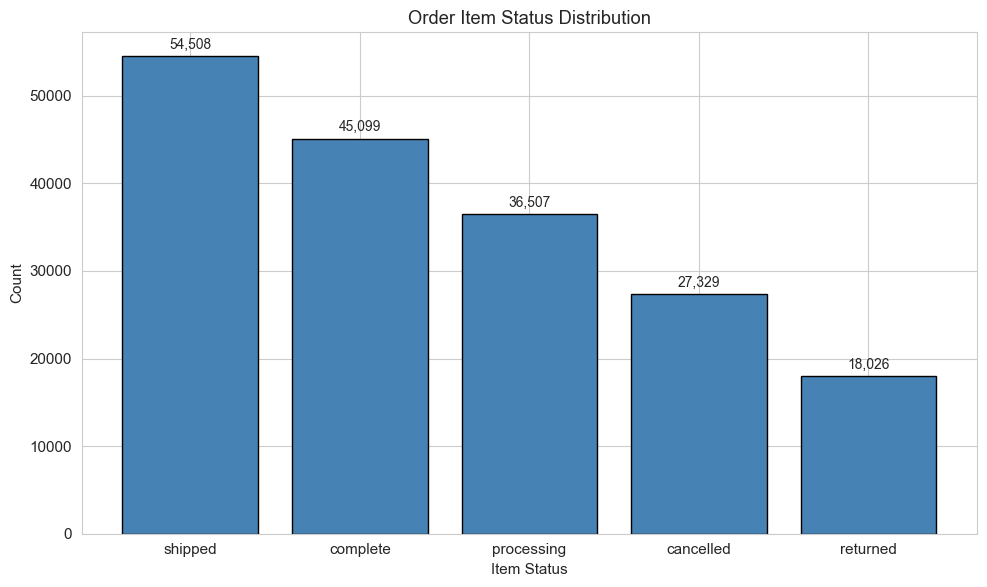

In [13]:
# Visualize status distribution
fig = plot_status_distribution(df)
plt.show()

### 5.2 Return Rate Analysis by Category

In [14]:
# Return rate by category and brand
ret_by_cat_brand = calculate_return_rates_by_group(
    df, 
    group_cols=["category", "brand"], 
    min_rows=200
)
ret_by_cat_brand.head(20)

item_rows  \
category                      brand                                  
fashion hoodies & sweatshirts volcom                           362   
tops & tees                   volcom                           277   
swim                          billabong                        217   
pants & capris                jones new york                   205   
intimates                     ilusion                          304   
                              calvin klein                     239   
                              barely there                     224   
leggings                      sk hat shop                      209   
accessories                   ray-ban                          677   
fashion hoodies & sweatshirts fox                              442   
jeans                         calvin klein jeans               256   
active                        exofficio                        234   
jeans                         rock revival                     210   
tops & tees                   allegra k                        574   
leggings                      anna-kaci                        203   
fashion hoodies & sweatshirts quiksilver                       236   
active                        columbia                         337   
jeans                         not your daughter's jeans        479   
                              volcom                           224   
socks & hosiery               hue                              291   

                                                         returned_items  \
category                      brand                                       
fashion hoodies & sweatshirts volcom                                 52   
tops & tees                   volcom                                 39   
swim                          billabong                              29   
pants & capris                jones new york                         27   
intimates                     ilusion                                40   
                              calvin klein                           31   
                              barely there                           29   
leggings                      sk hat shop                            27   
accessories                   ray-ban                                87   
fashion hoodies & sweatshirts fox                                    56   
jeans                         calvin klein jeans                     32   
active                        exofficio                              29   
jeans                         rock revival                           26   
tops & tees                   allegra k                              71   
leggings                      anna-kaci                              25   
fashion hoodies & sweatshirts quiksilver                             29   
active                        columbia                               41   
jeans                         not your daughter's jeans              58   
                              volcom                                 27   
socks & hosiery               hue                                    35   

                                                         return_rate  
category                      brand                                   
fashion hoodies & sweatshirts volcom                        0.143646  
tops & tees                   volcom                        0.140794  
swim                          billabong                     0.133641  
pants & capris                jones new york                0.131707  
intimates                     ilusion                       0.131579  
                              calvin klein                  0.129707  
                              barely there                  0.129464  
leggings                      sk hat shop                   0.129187  
accessories                   ray-ban                       0.128508  
fashion hoodies & sweatshirts fox                           0.126697  
jeans        

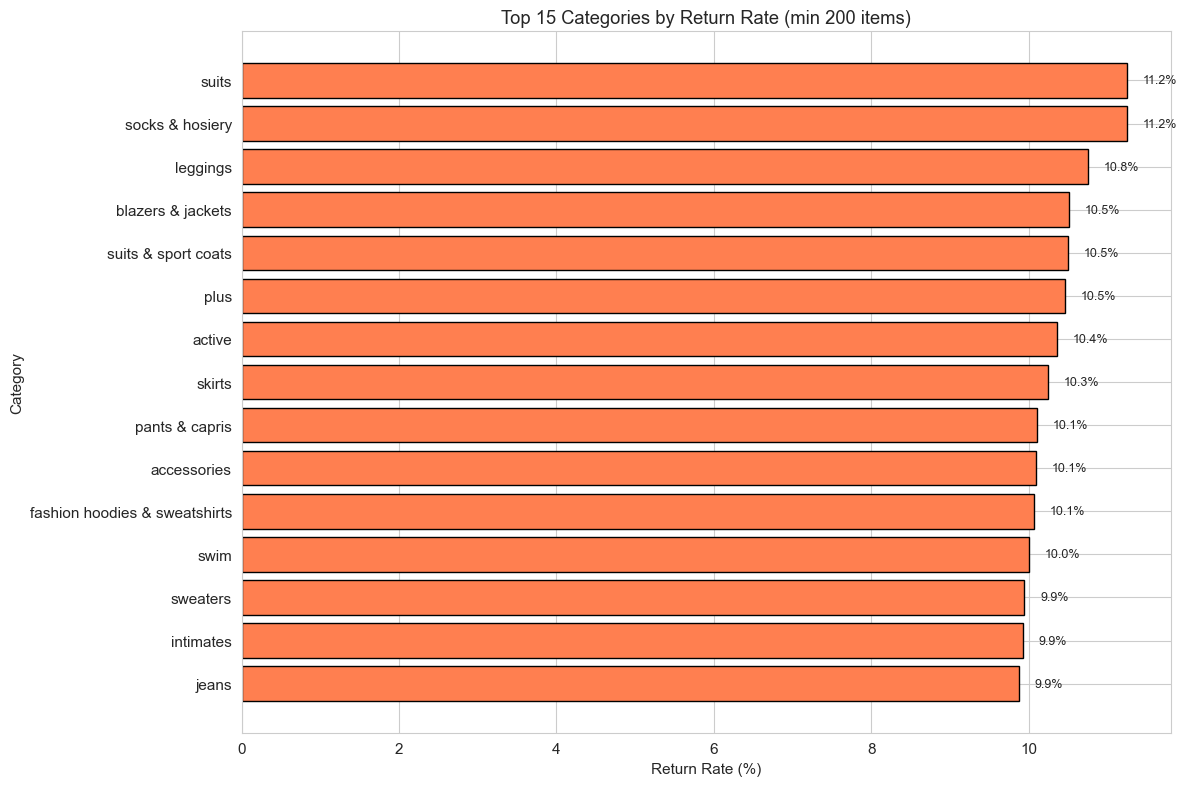

In [15]:
# Visualize return rates by category
fig = plot_return_rate_by_category(df, top_n=15, min_rows=200)
plt.show()

### 5.3 Margin Loss by Category

In [16]:
# Margin loss by category
margin_loss_by_category = calculate_margin_loss_by_group(df, group_cols=["category"])
margin_loss_by_category.head(15)

,returned_items,total_lost_sales,total_lost_margin,median_margin_per_return,avg_margin_per_return
category,,,,,
outerwear & coats,910,138556.649809,76907.674977,61.029501,84.513929
jeans,1243,122418.070154,57149.350833,35.835519,45.976952
sweaters,1099,84183.119906,43492.656858,31.705469,39.574756
suits & sport coats,529,68225.439934,40903.022480,60.293969,77.321404
swim,1114,62137.190199,30462.503862,21.905070,27.345156
fashion hoodies & sweatshirts,1189,62974.420089,30266.220279,23.430000,25.455189
active,962,48479.139997,28125.507598,19.544560,29.236494
sleep & lounge,1084,51599.420131,26914.815448,18.515895,24.829166
accessories,994,43475.109945,26059.085902,14.862625,26.216384


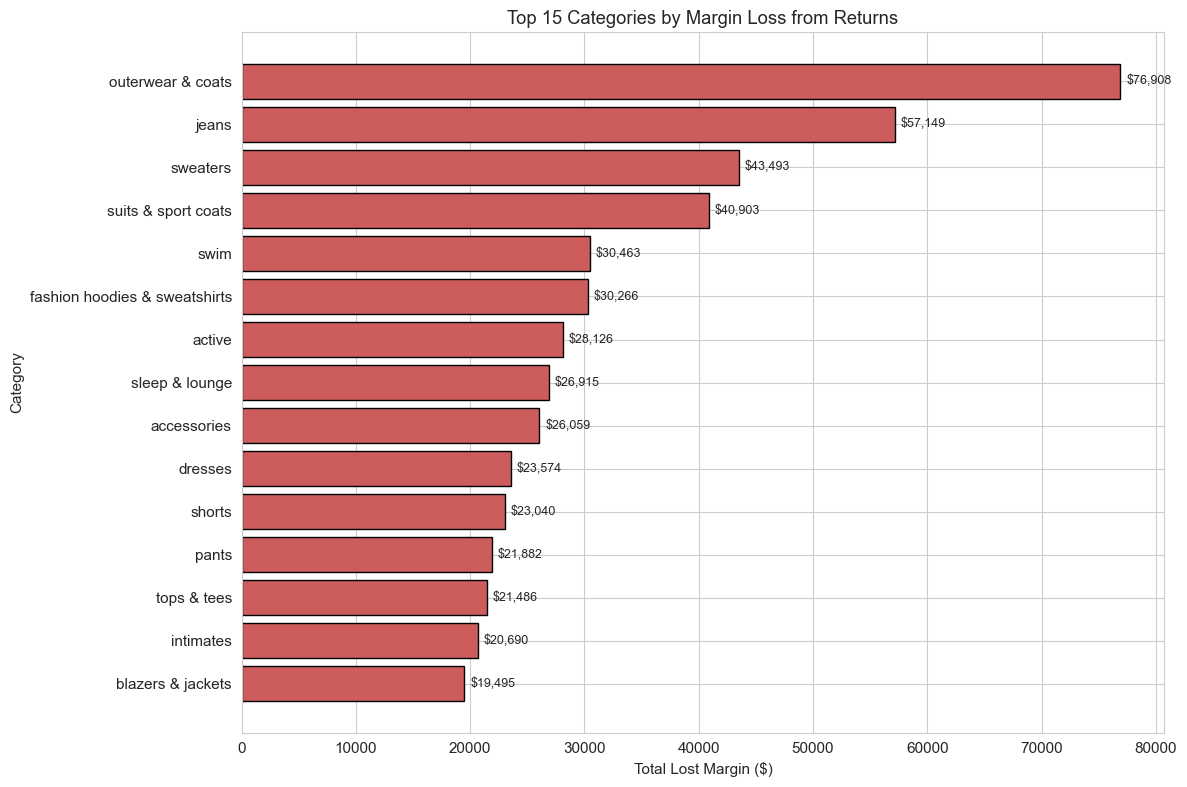

In [17]:
# Visualize margin loss by category
fig = plot_margin_loss_by_category(df, top_n=15)
plt.show()

### 5.4 Profit Erosion Summary

In [18]:
# Profit erosion by category (using category-tiered costs)
print("=" * 60)
print("PROFIT EROSION BY CATEGORY")
print("=" * 60)

# Group profit erosion by category
erosion_by_category = (
    df_returned.groupby("category")
    .agg(
        returned_items=("order_item_id", "count"),
        total_margin_reversal=("margin_reversal", "sum"),
        total_process_cost=("process_cost", "sum"),
        total_profit_erosion=("profit_erosion", "sum"),
        avg_erosion_per_item=("profit_erosion", "mean"),
    )
    .sort_values("total_profit_erosion", ascending=False)
    .round(2)
)

print(f"\nTop 10 categories by profit erosion:")
erosion_by_category.head(10)

PROFIT EROSION BY CATEGORY

Top 10 categories by profit erosion:


,returned_items,total_margin_reversal,total_process_cost,total_profit_erosion,avg_erosion_per_item
category,,,,,
outerwear & coats,910,76907.67,14196.0,91103.67,100.11
jeans,1243,57149.35,19390.8,76540.15,61.58
sweaters,1099,43492.66,17144.4,60637.06,55.17
suits & sport coats,529,40903.02,8252.4,49155.42,92.92
fashion hoodies & sweatshirts,1189,30266.22,16408.2,46674.42,39.26
swim,1114,30462.50,15373.2,45835.70,41.15
sleep & lounge,1084,26914.82,14959.2,41874.02,38.63
active,962,28125.51,13275.6,41401.11,43.04
accessories,994,26059.09,13717.2,39776.29,40.02


---

## 6. RQ2: Customer Segmentation

**Research Question**: What customer behavioral segments exist with differential profit erosion?

### 6.1 Customer Behavior Profile

In [19]:
# Customer behavior profile (using US06 customer features)
print("=" * 60)
print("CUSTOMER BEHAVIOR PROFILE")
print("=" * 60)

# Use customer_df which includes behavioral features and erosion
print(f"\nTotal customers: {len(customer_df):,}")
print(f"Customers with returns: {(customer_df['return_frequency'] > 0).sum():,}")

# Display summary of customer behavior
print("\n📊 Customer Behavior Summary:")
behavior_summary = customer_df[["order_frequency", "return_frequency", "customer_return_rate", 
                                 "avg_order_value", "total_profit_erosion"]].describe().round(2)
behavior_summary

CUSTOMER BEHAVIOR PROFILE

Total customers: 79,935
Customers with returns: 11,790

📊 Customer Behavior Summary:


,order_frequency,return_frequency,customer_return_rate,avg_order_value,total_profit_erosion
count,79935.00,79935.00,79935.00,79935.00,79935.00
mean,1.56,0.23,0.10,86.80,10.11
std,0.86,0.64,0.27,83.51,33.81
min,1.00,0.00,0.00,0.02,0.00
25%,1.00,0.00,0.00,34.99,0.00
50%,1.00,0.00,0.00,62.99,0.00
75%,2.00,0.00,0.00,110.75,0.00
max,4.00,8.00,1.00,1406.40,723.81


### 6.2 Customer Segmentation by Return Behavior

In [20]:
# Segment customers by return behavior
customer_segments = segment_customers_by_return_behavior(
    df, 
    return_rate_thresholds=(0.05, 0.15)
)

# Segment distribution
segment_counts = customer_segments["return_segment"].value_counts()
print("Customer Segment Distribution:")
print(segment_counts)
print(f"\nTotal customers: {len(customer_segments):,}")

Customer Segment Distribution:
return_segment
no_returns           68145
high_returner        11556
moderate_returner      234
Name: count, dtype: int64

Total customers: 79,935


In [21]:
# Analyze segments
segment_summary = (
    customer_segments
    .groupby("return_segment")
    .agg(
        customer_count=("total_items", "count"),
        avg_items=("total_items", "mean"),
        # avg_returns=("return_events", "mean"),
        avg_return_rate=("customer_return_rate", "mean"),
        total_margin=("total_margin", "sum"),
    )
    .round(2)
)
segment_summary

,customer_count,avg_items,avg_return_rate,total_margin
return_segment,,,,
high_returner,11556,2.80,0.68,1009489.15
moderate_returner,234,7.50,0.13,53056.95
no_returns,68145,2.16,0.00,4578946.81


### 6.3 Customer Margin Exposure

In [22]:
# Customer margin exposure
customer_exposure = calculate_customer_margin_exposure(df)
customer_exposure.head(20)

,return_events,total_lost_margin,total_lost_sales,median_margin_per_return,max_single_return_margin
user_id,,,,,
38929,4,666.809998,1188.500000,72.084000,511.097998
90574,5,641.914120,1219.440002,24.170400,489.409999
16299,4,639.041157,1109.549997,44.695039,533.672998
89510,4,604.945808,1018.930000,26.163905,539.993998
11692,4,585.446499,1096.500000,44.915000,483.104998
15431,1,568.099998,950.000000,568.099998,568.099998
25933,1,568.099998,950.000000,568.099998,568.099998
38754,4,567.898833,1059.960003,34.750481,482.202002
30688,2,552.005998,945.000000,276.002999,529.157998


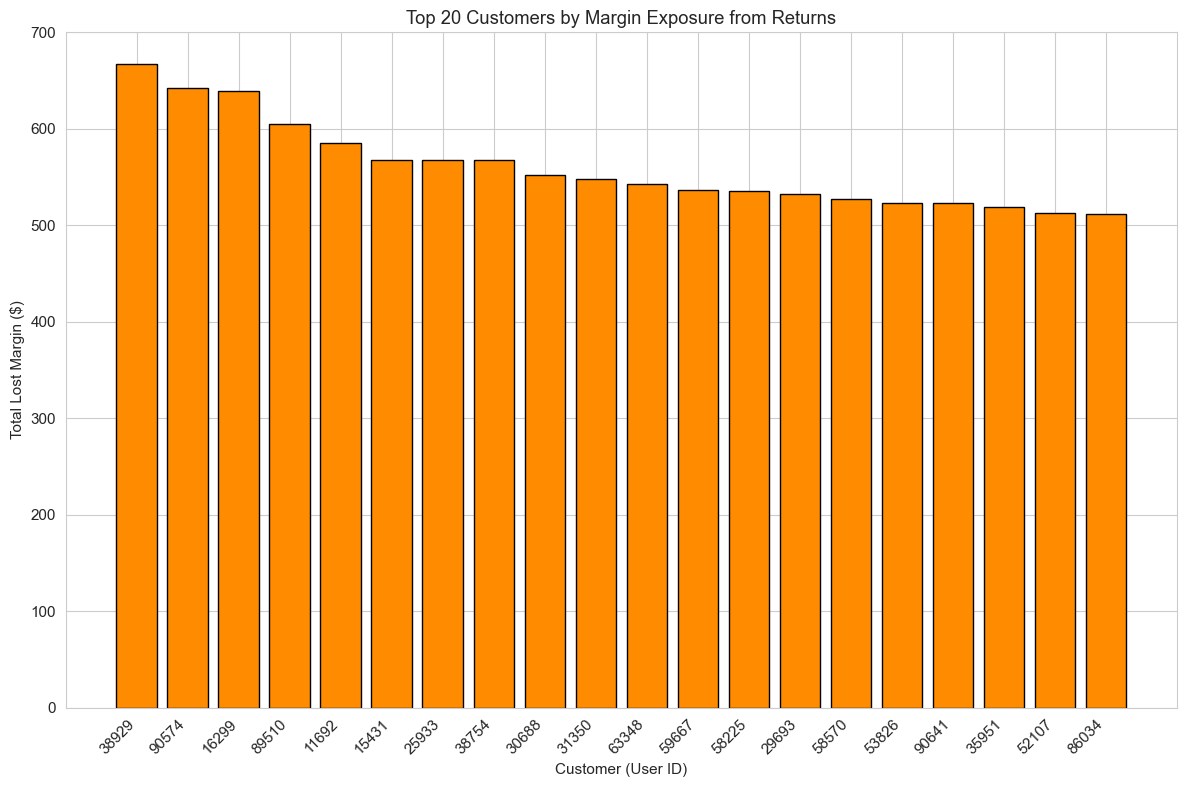

In [23]:
# Visualize customer margin exposure
fig = plot_customer_margin_exposure(df, top_n=20)
plt.show()

---

## 7. RQ3: Predictive Modeling

**Research Question**: Can we predict high profit erosion customers with AUC > 0.70?

*TODO: Implement predictive modeling*

In [24]:
# RQ3: Predictive Modeling - Data Ready
print("=" * 60)
print("RQ3: PREDICTIVE MODELING - DATA PREPARED")
print("=" * 60)

print("\n✅ Target variable created: is_high_erosion_customer")
print(f"   - Threshold: 75th percentile (${threshold:.2f})")
print(f"   - High erosion customers: {customer_targets['is_high_erosion_customer'].sum():,}")
print(f"   - Normal customers: {(customer_targets['is_high_erosion_customer'] == 0).sum():,}")

print("\n✅ Features available for modeling:")
feature_cols = [col for col in customer_targets.columns 
                if col not in ["user_id", "is_high_erosion_customer", "profit_erosion_quartile", 
                               "erosion_percentile_rank", "total_profit_erosion"]]
for col in feature_cols[:10]:
    print(f"   - {col}")
if len(feature_cols) > 10:
    print(f"   ... and {len(feature_cols) - 10} more")

print("\n📋 Next Steps:")
print("  1. Feature selection and preprocessing")
print("  2. Train/test split with temporal consideration")
print("  3. Model training (Logistic Regression, Random Forest, XGBoost)")
print("  4. Evaluation metrics (target AUC > 0.70)")

RQ3: PREDICTIVE MODELING - DATA PREPARED

✅ Target variable created: is_high_erosion_customer
   - Threshold: 75th percentile ($87.46)
   - High erosion customers: 2,948
   - Normal customers: 8,842

✅ Features available for modeling:
   - total_items
   - order_frequency
   - return_frequency
   - total_sales
   - total_margin
   - avg_item_price
   - avg_item_margin
   - customer_return_rate
   - avg_basket_size
   - purchase_recency_days
   ... and 4 more

📋 Next Steps:
  1. Feature selection and preprocessing
  2. Train/test split with temporal consideration
  3. Model training (Logistic Regression, Random Forest, XGBoost)
  4. Evaluation metrics (target AUC > 0.70)


---

## 8. RQ4: Econometric Analysis

**Research Question**: What are the marginal associations between customer behaviors and profit erosion?

*TODO: Implement regression analysis*

In [25]:
# Placeholder for econometric analysis
print("RQ4: Econometric Regression - To be implemented")
print("\nPlanned approach:")
print("  1. Define dependent variable (profit erosion per customer)")
print("  2. Select independent variables (demographics, behavior metrics)")
print("  3. OLS regression with robust standard errors")
print("  4. Coefficient interpretation and marginal effects")
print("  5. Model diagnostics (heteroscedasticity, multicollinearity)")

RQ4: Econometric Regression - To be implemented

Planned approach:
  1. Define dependent variable (profit erosion per customer)
  2. Select independent variables (demographics, behavior metrics)
  3. OLS regression with robust standard errors
  4. Coefficient interpretation and marginal effects
  5. Model diagnostics (heteroscedasticity, multicollinearity)


---

## 9. Summary & Conclusions

*To be completed after all analyses*

In [26]:
# US06 Feature Engineering Summary
print("=" * 60)
print("US06 FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset Statistics:")
print(f"  Total order items: {len(df):,}")
print(f"  Returned items: {len(df_returned):,}")
print(f"  Return rate: {len(df_returned) / len(df) * 100:.2f}%")

print(f"\n💰 Profit Erosion (Category-Tiered Costs):")
print(f"  Total margin reversal: ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"  Total processing costs: ${erosion_summary['total_process_costs']:,.2f}")
print(f"  TOTAL PROFIT EROSION: ${erosion_summary['total_profit_erosion']:,.2f}")

print(f"\n👥 Customer Analysis:")
print(f"  Total customers: {len(customer_df):,}")
print(f"  Customers with returns: {len(customer_targets):,}")
print(f"  High erosion customers (Q4): {customer_targets['is_high_erosion_customer'].sum():,}")

print(f"\n✅ Datasets Saved:")
print(f"  - feature_engineered_dataset.parquet ({len(df):,} rows)")
print(f"  - customer_profit_erosion_targets.parquet ({len(customer_targets):,} rows)")

print("\n" + "=" * 60)

US06 FEATURE ENGINEERING SUMMARY

📊 Dataset Statistics:
  Total order items: 181,469
  Returned items: 18,026
  Return rate: 9.93%

💰 Profit Erosion (Category-Tiered Costs):
  Total margin reversal: $558,911.87
  Total processing costs: $249,340.20
  TOTAL PROFIT EROSION: $808,252.07

👥 Customer Analysis:
  Total customers: 79,935
  Customers with returns: 11,790
  High erosion customers (Q4): 2,948

✅ Datasets Saved:
  - feature_engineered_dataset.parquet (181,469 rows)
  - customer_profit_erosion_targets.parquet (11,790 rows)

